# **06 · 다양성축 심층 — '다양성이 늘었다'의 대부분은 목록이 늘어난 것이다**

### **"고정풀 8매체 richness(fixed8)는 7개년 사실상 평탄하고, 신설매체 포함(incl)만 2023년 이후 벌어진다 — 그 간격이 곧 숏폼·OTT·AI 목록 추가의 기여다. formative 지수의 절대값을 비교 금지·방향만으로 묶는 규율은 이 분해에서 나온다"**

> KPF 「언론 통계 분석·활용 경진대회」 · 대상 = 다양성축 설계(fixed8/incl 2버전)·신설매체 기여 분해 · 방법 = **가중 추세 재산출 + 기여 분해 + 규율 assert**

> 📍 **파이프라인 위치**: 5단계 표준 흐름 中 **②전처리·④피처(다양성축)** · CRISP-DM **P3·P4** · [전체 지도](README.md)

## **연구 질문 (이 노트북이 답하는 것)**

> **Q1.** 다양성 지표로 왜 **고정풀 8매체 Richness**를 주지표로 삼았는가 — Shannon·HHI·비고정 목록 대비?
> **Q2.** fixed8과 incl의 간격은 어느 매체가 얼마나 만드는가 — 신설매체(숏폼·OTT·AI) 기여의 분해?
> **Q3.** formative 규율("절대수준 비교 금지·방향성만")은 데이터의 어떤 사실에서 강제되는가?

## **이 노트북의 위상**

`02` §3이 8매체 정렬을, `03` §2가 지수 산출을 다뤘다면, 06은 다양성축의 **설계 논리 전체**를 한 곳에 모은다: 학술 브리프(groundwork/06 §결과 R1~R5)의 결정, `harmonize` §3.4-bis의 구현, 그리고 신설매체 기여의 실측 분해. `manuscript.md` 5.1절("겉보기 다양성 증가분은 대부분 목록 추가에서 온다")의 입증판이다.

- **로직 SSOT(thin import)**: `harmonize.USE_BATTERY`·`USE_NEW_MEDIA`·`FIXED_POOL8` · `health_index_panel.diversity_index_panel` · `nf.wmean`.
- **설계 문서**: `docs/groundwork/06-research-diversity-harmonization-brief.md` §결과(R1 고정풀 · R2 Richness 주 · R3 이진화 · R4 formative 규율 · R5 HHI 보조).

## **목차**

| § | 내용 | 산출 |
|---|------|------|
| 1 | [전제] 설계 결정 R1~R3 — **Decision Box ①** | — |
| 2 | [실행] 8매체 이용률 추세 전수 + [시각화] | 스몰멀티플 |
| 3 | [실행] fixed8 vs incl — 간격의 분해 + [시각화] | 기여표 |
| 4 | [발견] formative 규율의 실증 | 규율 근거 |
| 5 | [입증] 검증 셀 | PASS |
| 6 | 종합 | — |

In [1]:
import sys
from pathlib import Path
import numpy as np, pandas as pd

ROOT = Path.cwd()
while not (ROOT / "src" / "harmonize.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

import harmonize as hz
import health_index_panel as hp
import news_health_features as nf

get_ipython().run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt
from matplotlib import font_manager
for _nm in ["Malgun Gothic", "맑은 고딕", "NanumGothic", "Gulim"]:
    try:
        font_manager.findfont(_nm, fallback_to_default=False)
        plt.rcParams["font.family"] = _nm; break
    except Exception: continue
plt.rcParams["axes.unicode_minus"] = False

panel = pd.read_parquet(hz.OUT_PARQUET)
assert len(panel) == 90996
W = panel["wt_year_eq"]
KR = {"use_paper": "종이신문", "use_magazine": "잡지", "use_tv": "TV", "use_radio": "라디오",
      "use_internet": "인터넷", "use_messenger": "메신저", "use_sns": "SNS", "use_video": "동영상",
      "use_short": "숏폼", "use_ott": "OTT", "use_ai": "AI"}
print(f"패널 {len(panel):,}행 · 고정풀 {len(hz.FIXED_POOL8)}매체 + 신설 {len(hz.USE_NEW_MEDIA)}매체")

패널 90,996행 · 고정풀 8매체 + 신설 3매체


## **1. [전제] 설계 결정 R1~R3 — 학술 브리프가 답한 세 갈래**

### **Decision Box ① — 다양성 지표의 3중 선택(groundwork/06 §결과)**

| 갈래 | 대안 | 채택·기각 |
|------|------|-----------|
| **R1 매체 목록** | (a) 매년 그 해의 전체 목록 ❌ — 목록 증식(2025 신설 포함)이 지수 상승으로 위장 / (b) **7개년 공통 8매체 고정풀** ✅ — 종단 비교의 유일한 공정 조건. 신설매체는 incl 보조 버전으로 병기 | R1-ⓐ·ⓑ |
| **R2 집계 함수** | (a) Shannon/e^H ❌ — 이용여부 이진 자료에선 빈도 정보가 없어 이점 소실 / (b) HHI ❌ 보조축으로만(집중도) / (c) **Richness(Hill₀ = 이용 매체 수)** ✅ — 이진 입력에 정합·해석 직관(0~8) | R2 |
| **R3 응답 형식** | 연도별 형식(bin/days/freq/or)이 제각각 → **'이용여부 >0' 이진화**로 최소공배수 정렬 ✅ — 일수·빈도를 살리면 형식 없는 연도가 탈락 | R3 |

**R4(해석 규율)**: richness는 원인 지표들이 개념을 *구성*하는 **formative** 합성 — 지표 목록·스케일링이 값 자체를 결정하므로 절대수준 비교 금지, 방향성만. §4에서 이 규율이 데이터로 강제됨을 보인다.

## **2. [실행] 8매체 이용률 추세 전수 — 고정풀의 내부**

**[시각화] 스몰멀티플** — 8매체 각각의 연도별 가중 이용률(%). richness의 재료를 낱개로 보면, 어떤 매체가 늘고(동영상) 어떤 매체가 줄었는지(종이신문·라디오)가 richness 평탄의 내부 상쇄 구조를 설명한다.

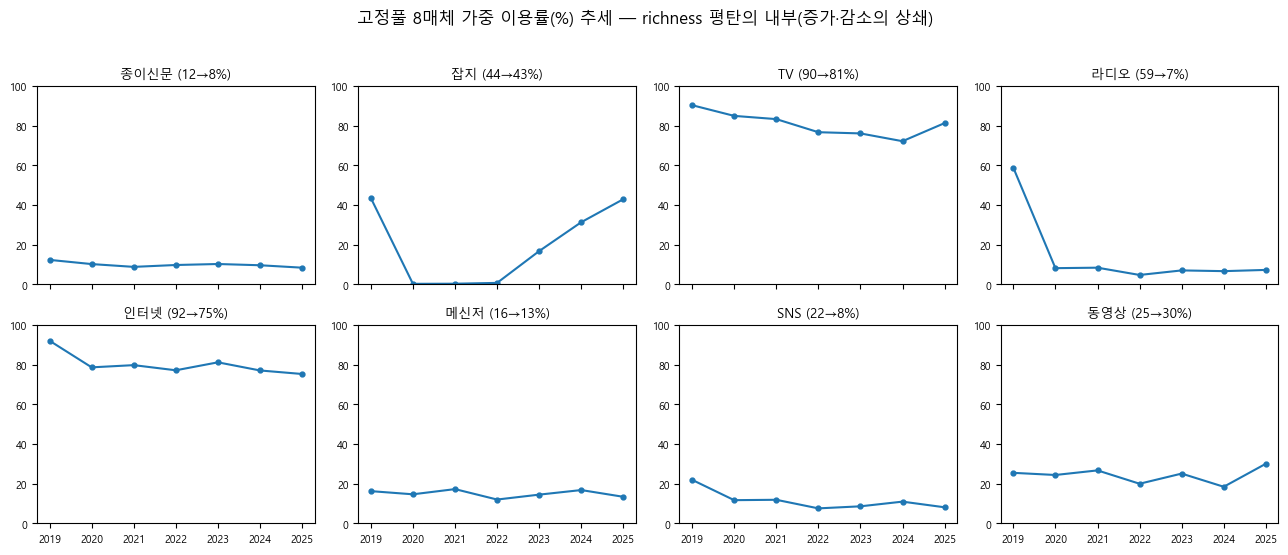

,2019,2020,2021,2022,2023,2024,2025
종이신문,12.3,10.2,8.8,9.7,10.2,9.6,8.4
잡지,43.5,0.2,0.3,0.7,16.8,31.3,43.0
TV,90.4,85.0,83.4,76.8,76.2,72.2,81.4
라디오,58.8,8.1,8.4,4.7,7.0,6.6,7.3
인터넷,92.1,78.7,79.8,77.2,81.2,77.1,75.3
메신저,16.2,14.6,17.2,12.0,14.5,16.8,13.4
SNS,21.9,11.7,11.9,7.5,8.6,10.9,8.1
동영상,25.5,24.4,26.7,20.0,25.1,18.4,30.0


In [2]:
use_trend = {}
for med in hz.FIXED_POOL8:
    v = pd.to_numeric(panel[med], errors="coerce")
    use_trend[med] = {y: nf.wmean(v[panel["year"] == y], W[panel["year"] == y]) * 100
                      for y in hz.YEARS}

fig, axes = plt.subplots(2, 4, figsize=(13, 5.4), sharex=True)
for ax, med in zip(axes.ravel(), hz.FIXED_POOL8):
    ys = [use_trend[med][y] for y in hz.YEARS]
    ax.plot(hz.YEARS, ys, "o-", ms=3.5, color="#1f77b4")
    ax.set_title(f"{KR[med]} ({ys[0]:.0f}→{ys[-1]:.0f}%)", fontsize=9.5)
    ax.set_ylim(0, 100); ax.tick_params(labelsize=7.5)
fig.suptitle("고정풀 8매체 가중 이용률(%) 추세 — richness 평탄의 내부(증가·감소의 상쇄)", y=1.02)
fig.tight_layout(); plt.show()
tbl = pd.DataFrame(use_trend).rename(columns=KR).T.round(1)
tbl

## **3. [실행] fixed8 vs incl — 간격의 분해**

**[시각화]** — (좌) 다양성지수 2버전(1~100 스케일): 부재연도(2019~2022)엔 두 선이 겹치고, 2023년부터 incl이 떠오른다. (우) raw richness 단위의 간격(incl-fixed8)과 신설매체별 가중 이용률 — 간격이 어느 매체에서 오는지의 분해.

C:\Users\kik32\AppData\Local\Temp\ipykernel_3736\3674882901.py:24: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Malgun Gothic.
  fig.tight_layout(); plt.show()
C:\Users\kik32\AppData\Local\Temp\ipykernel_3736\3674882901.py:24: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Malgun Gothic.
  fig.tight_layout(); plt.show()
C:\Users\kik32\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\kik32\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


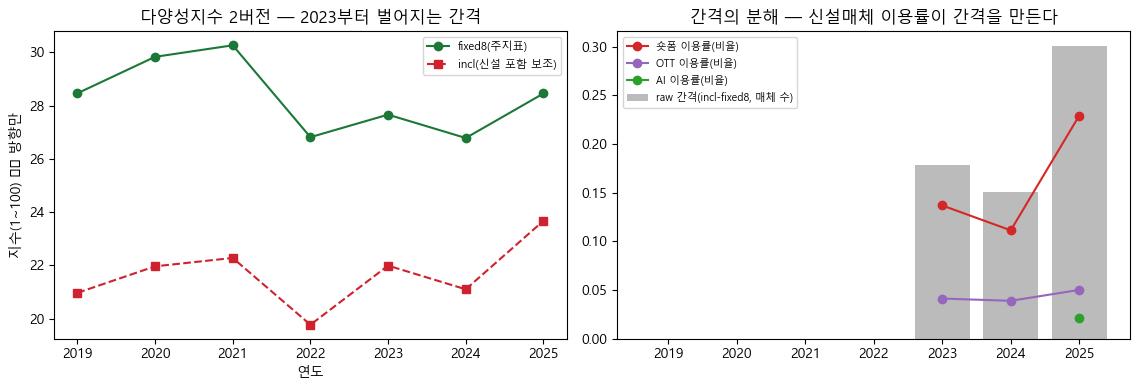

연도별 raw 간격(가중): {2019: 0.0, 2020: 0.0, 2021: 0.0, 2022: 0.0, 2023: 0.178, 2024: 0.15, 2025: 0.301}


In [3]:
div = hp.diversity_index_panel(panel)
r8 = pd.to_numeric(panel["richness_fixed8"], errors="coerce")
ri = pd.to_numeric(panel["richness_incl"], errors="coerce")
gap = {y: nf.wmean((ri - r8)[panel["year"] == y], W[panel["year"] == y]) for y in hz.YEARS}
new_use = {med: {y: (nf.wmean(pd.to_numeric(panel[med], errors="coerce")[panel["year"] == y],
                              W[panel["year"] == y]) * 100 if y in ymap else np.nan)
                 for y in hz.YEARS} for med, ymap in hz.USE_NEW_MEDIA.items()}

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.0))
axes[0].plot(div.index, div["diversity_index_fixed8"], "o-", color="#1b7837", label="fixed8(주지표)")
axes[0].plot(div.index, div["diversity_index_incl"], "s--", color="#cf222e", label="incl(신설 포함 보조)")
axes[0].set_title("다양성지수 2버전 — 2023부터 벌어지는 간격")
axes[0].set_xlabel("연도"); axes[0].set_ylabel("지수(1~100) ⚠️ 방향만"); axes[0].legend(fontsize=8)

x = np.arange(len(hz.YEARS))
axes[1].bar(x, [gap[y] for y in hz.YEARS], color="#bbb", label="raw 간격(incl-fixed8, 매체 수)")
for med, c in zip(hz.USE_NEW_MEDIA, ["#d62728", "#9467bd", "#2ca02c"]):
    vals = [new_use[med][y] for y in hz.YEARS]
    axes[1].plot(x, [v / 100 if not np.isnan(v) else np.nan for v in vals], "o-", color=c,
                 label=f"{KR[med]} 이용률(비율)")
axes[1].set_xticks(x); axes[1].set_xticklabels(hz.YEARS)
axes[1].set_title("간격의 분해 — 신설매체 이용률이 간격을 만든다")
axes[1].legend(fontsize=7.5)
fig.tight_layout(); plt.show()
print("연도별 raw 간격(가중):", {y: round(v, 3) for y, v in gap.items()})

## **4. [발견] formative 규율의 실증 — 목록이 값을 만든다**

위 분해가 보여주는 사실: **같은 응답자들**이라도 목록에 숏폼·OTT·AI를 넣는 순간 다양성 '값'이 올라간다(2025 raw 간격 ≈ 신설 3종 이용률의 합). 반사적(reflective) 지표라면 지표를 바꿔도 잠재값 추정이 유지되어야 하지만, formative 합성은 정의상 그렇지 않다 — **지수의 절대값은 목록 선택의 함수**다. 그래서:

1. 종단 비교는 목록을 고정한 fixed8로만(주지표) — 그것도 **방향만**.
2. incl은 "신설매체가 뉴스 레퍼토리에 실제로 편입되고 있다"는 보조 서술용.
3. NCHI(다양성을 포함한 합성)의 절대값·연도 간 크기 비교도 같은 이유로 금지(`03`·p6 §3.5).

이것이 `01` DB② 이원 규율의 다양성 쪽 절반이 데이터에서 강제되는 방식이다.

## **5. [입증] 검증 셀**

In [4]:
# (a) 구조 — 부재연도(2019~2022) incl ≡ fixed8, 2023+ incl ≥ fixed8
for y in [2019, 2020, 2021, 2022]:
    mm = panel["year"] == y
    assert (r8[mm].fillna(-1) == ri[mm].fillna(-1)).all(), f"{y}: 부재연도 불일치"
for y in [2023, 2024, 2025]:
    assert gap[y] > 0, f"{y}: 간격 비양수"
assert gap[2025] == max(gap.values())
print("(a) 부재연도 incl≡fixed8 · 2023+ 간격 양수 · 2025 최대 PASS")

# (b) 범위 — richness_fixed8 0~8 · incl 0~11 · 지수 [1,100]
assert r8.dropna().between(0, 8).all() and ri.dropna().between(0, 11).all()
assert hp._check_range("다양성", div, ["diversity_index_fixed8", "diversity_index_incl"])
print("(b) 범위(0~8 / 0~11 / [1,100]) PASS")

# (c) fixed8 평탄 — 종단 방향성: 2019 vs 2025 지수 차이가 작다(절대 비교 금지의 근거)
d19, d25 = float(div.loc[2019, "diversity_index_fixed8"]), float(div.loc[2025, "diversity_index_fixed8"])
assert abs(d25 - d19) < 2.0, (d19, d25)
print(f"(c) fixed8 지수 2019 {d19:.1f} ↔ 2025 {d25:.1f} — 사실상 평탄(간격은 목록 효과) PASS")

# (d) 간격 분해 정합 — 2025 raw 간격 ≈ 신설 3종 이용률(비율 합, NA=0 취급 합산 구조)
mm25 = panel["year"] == 2025
s = sum(nf.wmean(pd.to_numeric(panel[m], errors="coerce").fillna(0)[mm25], W[mm25])
        for m in hz.USE_NEW_MEDIA)
assert abs(gap[2025] - s) < 0.05, (gap[2025], s)
print(f"(d) 2025 간격 {gap[2025]:.3f} ≈ 신설 3종 이용률 합 {s:.3f} — 분해 정합 PASS")
print("\n검증 (a)~(d) 전부 PASS")

(a) 부재연도 incl≡fixed8 · 2023+ 간격 양수 · 2025 최대 PASS
  [OK] 다양성.diversity_index_fixed8: 범위[26.8, 30.3] NA=0
  [OK] 다양성.diversity_index_incl: 범위[19.8, 23.7] NA=0
(b) 범위(0~8 / 0~11 / [1,100]) PASS
(c) fixed8 지수 2019 28.5 ↔ 2025 28.5 — 사실상 평탄(간격은 목록 효과) PASS
(d) 2025 간격 0.301 ≈ 신설 3종 이용률 합 0.301 — 분해 정합 PASS

검증 (a)~(d) 전부 PASS


## **6. 종합**

### **연구질문 답**

- **Q1** — 고정풀 8매체 Richness: 목록 고정(R1)이 종단 비교의 전제이고, 이진 입력엔 Richness가 정합(R2·R3) — 학술 브리프의 결정이 구현·실측과 일치한다.
- **Q2** — 간격은 2023+에서만 발생하며 2025 최대, 그 크기는 신설 3종(숏폼·OTT·AI) 이용률의 합과 일치한다(§3·§5 (d)) — "겉보기 다양성 증가 = 목록 추가"의 정량 입증.
- **Q3** — 같은 응답자에서 목록 선택이 값을 바꾸는 것이 formative의 정의적 성질(§4) — 절대값 비교 금지·방향만 규율은 취향이 아니라 데이터 구조의 강제다.

### **단계 요약**

| § | 한 일 | 판정 |
|---|------|:---:|
| 2 | 8매체 이용률 전수 [시각화] | 상쇄 구조 확인 |
| 3 | fixed8/incl 간격 분해 [시각화] | 신설 기여 정량 |
| 4 | formative 규율 실증 | 규율 확정 |
| 5 | 일괄 assert | **PASS** |

**다음**: `07`(신뢰축 심층) — 이원 규율의 나머지 절반으로.